
--- Starting Data Extraction & Histogramming ---
Extracting nominal data from 5 files...


/tmp/ipykernel_3214313/1948820805.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved fit plot to FatJetMass_Fit.pdf

--- Fit Results ---
MC Data   -> Mean: 88.791, Sigma: 8.223
Real Data -> Mean: 87.718, Sigma: 8.847
Scale Factor (Data/MC) -> JMS: 0.9879, JMR: 1.0759


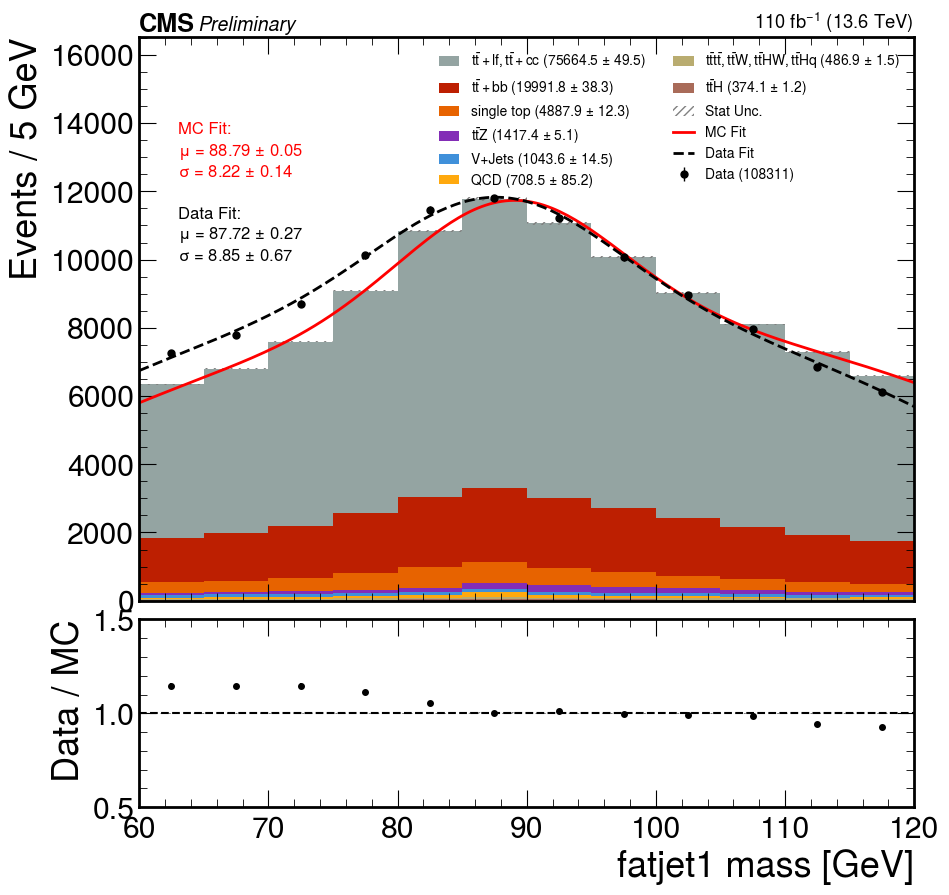

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.optimize import curve_fit
from matplotlib.backends.backend_pdf import PdfPages
from coffea.util import load

# ==========================================
# 1. GLOBAL SETTINGS & CONFIGURATION
# ==========================================
hep.style.use(hep.style.CMS)

COFFEA_DIR = "DataVsMC/" # <-- UPDATE THIS PATH
LUMI = 110 # in fb^-1 

# --- Processes ---
bkg_processes = ['VJets', 'QCD', 'tt_B', 'TTBar', 'SingleTop', 'TTX'] 
sig_processes = ['ttZ', 'ttH']
data_process = 'data_obs'
all_processes = bkg_processes + sig_processes + [data_process]

validation_vars = ['fatjet1_mass', 'fatjet1_pt']
cut_vars = ['ZH_bbvLscore', 'ZH_M', 'ZH_pt', 'n_b_outZH', 'n_ak4jets', 'MET_pt']

bkg_colors = {'VJets':'#3f90da', 'QCD':'#ffa90e', 'tt_B':'#bd1f01', 'TTBar':'#94a4a2', 'SingleTop':'#e76300', 'TTX':'#b9ac70'}
sig_colors = {'ttZ':'#832db6', 'ttH':'#a96b59'}
mc_colors = {**bkg_colors, **sig_colors}

process_labels = {
    'VJets': 'V+Jets', 'QCD': 'QCD', 'tt_B': r'$t\bar{t}+bb$',
    'TTBar': r'$t\bar{t} + lf, t\bar{t}+cc$', 'SingleTop': 'single top',
    'TTX': r'$t\bar{t}t\bar{t}, t\bar{t}W, t\bar{t}HW, t\bar{t}Hq$',
    'ttZ': r'$t\bar{t}Z$', 'ttH': r'$t\bar{t}H$', 'data_obs': 'Data'
}

# ==========================================
# 2. CUTS & DATA EXTRACTION
# ==========================================
def cuts(df_):
    base = (
        #(df_['n_ak4jets']   >= 5)       &
        #(df_['n_b_outZH']   == 2)       &
        (df_['fatjet1_pt'] > 200)       &
        (df_['ZH_M']        >= 50)      &
        (df_['MET_pt']      > 20)       &
        #(df_['ZH_bbvLscore'] > 0.5669)  &
        (df_['ZH_M']        <= 200)
    )
    return base

def getZhbbWeight(df_, year=None):
    if 'norm_weight' not in df_.columns:
        return pd.Series(1.0, index=df_.index) 
    weight = df_['norm_weight'].copy()
    gen_w = df_.get('genWeight', pd.Series(1.0, index=df_.index)).fillna(1.0)
    weight *= np.sign(gen_w)
    sfs = ['ele_reco_sf', 'ele_id_sf', 'mu_id_sf', 'mu_iso_sf', 'puWeight', 'mu_trig_sf','topptWeight', 'btag_sf']
    for sf in sfs:
        sf_col = df_.get(sf, pd.Series(1.0, index=df_.index)).fillna(1.0)
        weight *= sf_col
    return weight

def load_and_cut_nominal_data(coffea_dir=COFFEA_DIR, year=2024):
    tracked_data = {proc: {} for proc in all_processes}
    valid_files = [f for f in glob.glob(os.path.join(coffea_dir, "*.coffea")) if 'nom' in os.path.basename(f).lower()]
    print(f"Extracting nominal data from {len(valid_files)} files...")

    # Global unskimmed nominal genweights (DAS ground-truth sums)
    target_weights = {
        'tttolnu2q_2024': 480547550.0, 
        'ttto2l2nu_2024': 466318140.0, 
        'ttto4q_2024': 468705400.0,
        'ttbbtolnu2q_2024': 21007254.0, 
        'ttbbto2l2nu_2024': 11683236.0, 
        'ttbbto4q_2024': 14012432.0
    }

    # Extract global nominal genweights, overriding with target_weights where applicable
    nom_genweights = {}
    for file_path in valid_files:
        filein = load(file_path)
        gw_dict = filein.get('sum_signOf_genweights', {})
        for dataset, weight in gw_dict.items():
            if isinstance(weight, dict):
                for sub_dataset, sub_weight in weight.items():
                    clean_name = sub_dataset.lower().replace('_2023', '').replace('_2022', '')
                    nom_genweights[sub_dataset] = target_weights.get(clean_name, sub_weight)
            else:
                clean_name = dataset.lower().replace('_2023', '').replace('_2022', '')
                nom_genweights[dataset] = target_weights.get(clean_name, weight)

    for file_path in valid_files:
        filein = load(file_path)
        for raw_proc in filein['columns'].keys():
            mapped_proc = None
            if 'TTTo' in raw_proc: mapped_proc = 'TTBar' if 'tt+B' not in raw_proc else None
            elif 'TTbb' in raw_proc: mapped_proc = 'tt_B' if 'tt+B' in raw_proc else None
            elif 'WJets' in raw_proc or 'DYJets' in raw_proc: mapped_proc = 'VJets'
            elif 'QCD' in raw_proc: mapped_proc = 'QCD'
            elif 'ttH' in raw_proc or 'tth' in raw_proc.lower(): mapped_proc = 'ttH'
            elif 'TTZ' in raw_proc or 'ttz' in raw_proc.lower() or 'TTLL' in raw_proc or 'TTNuNu' in raw_proc: mapped_proc = 'ttZ'
            elif 'DATA' in raw_proc or 'data' in raw_proc.lower(): mapped_proc = 'data_obs'
            elif 'SingleTop' in raw_proc: mapped_proc = 'SingleTop'
            elif 'TTX' in raw_proc: mapped_proc = 'TTX'
            
            if mapped_proc not in all_processes: continue
                
            for dataset in filein['columns'][raw_proc].keys():
                genweight = nom_genweights.get(dataset, 1.0) 
                try:
                    base_dict = filein['columns'][raw_proc][dataset]['btag_mask']['nominal']
                except KeyError:
                    continue 
                    
                current_vars = validation_vars + cut_vars + (['norm_weight'] if mapped_proc != 'data_obs' else [])
                tmp_data = {}
                
                for var in current_vars:
                    dict_key = f'spanet_output_{var}' if var in ['ttzbb', 'tthbb', 'ttbb', 'ttlf', 'ttcc', 'signal'] else f'events_{var}'
                    if dict_key in base_dict:
                        arr = np.array(base_dict[dict_key].value)
                        tmp_data[var] = arr / genweight if (var == 'norm_weight' and mapped_proc != 'data_obs') else arr
                        
                if tmp_data: 
                    df = pd.DataFrame(tmp_data)
                    if dataset not in tracked_data[mapped_proc]:
                        tracked_data[mapped_proc][dataset] = []
                    tracked_data[mapped_proc][dataset].append(df)

    data_dict = {}
    for proc in all_processes:
        dfs_to_concat = [df for dataset in tracked_data[proc].values() for df in dataset]
        if dfs_to_concat:
            df = pd.concat(dfs_to_concat, ignore_index=True)
            df = df[cuts(df)] 
            df['tot_weight'] = getZhbbWeight(df, year=year) if proc != 'data_obs' else 1.0
            data_dict[proc] = df
        else:
            data_dict[proc] = None
    return data_dict

# ==========================================
# 3. FITTING FUNCTIONS
# ==========================================
def fit_func(x, l, q, x0, a, b, c):
    """Quadratic background + Gaussian signal"""
    quadratic = q * np.power(x, 2) + l * x + x0
    gaussian  = a * np.exp(-1.0 * np.power(x - b, 2) / (2.0 * np.power(c, 2)))
    return quadratic + gaussian

# ==========================================
# 4. PLOTTING & EXECUTION
# ==========================================
def run_mass_fit():
    print("\n--- Starting Data Extraction & Histogramming ---")
    data_dict = load_and_cut_nominal_data()
    
    # Setup Binning (60 to 120 GeV in 5 GeV increments)
    x_min, x_max, bin_width = 60, 120, 5
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    # Containers
    mc_processes = bkg_processes + sig_processes
    total_mc_counts = np.zeros(len(bins)-1)
    total_mc_err2 = np.zeros(len(bins)-1)
    mc_hists, mc_labels, mc_colors_list = [], [], []
    
    # Process MC
    for proc in mc_processes:
        df = data_dict[proc]
        if df is None or df.empty: continue
        
        vals = df['fatjet1_mass'].values
        weights = df['tot_weight'].values
        if proc == 'tt_B': weights *= 2.3 #1.318 # k-factor
            
        counts, _ = np.histogram(vals, bins=bins, weights=weights)
        err2, _ = np.histogram(vals, bins=bins, weights=weights**2)
        
        yield_total, stat_unc = np.sum(counts), np.sqrt(np.sum(err2))
        mc_hists.append(counts)
        mc_labels.append(f"{process_labels.get(proc, proc)} ({yield_total:.1f} ± {stat_unc:.1f})")
        mc_colors_list.append(mc_colors[proc])
        
        total_mc_counts += counts
        total_mc_err2 += err2
        
    total_mc_err = np.sqrt(total_mc_err2)
    
    # Process Data
    df_data = data_dict['data_obs']
    data_counts, _ = np.histogram(df_data['fatjet1_mass'].values, bins=bins)
    data_err = np.sqrt(data_counts)
    
    # --- FIT MC ---
    # Initial Guess: l=0, q=0, x0=bkg_level, a=peak_height, b=85, c=8
    p0_mc = [0, 0, np.mean(total_mc_counts), np.max(total_mc_counts), 85, 8]
    # Replace zero errors with 1 to avoid division by zero in curve_fit
    mc_fit_err = np.where(total_mc_err == 0, 1.0, total_mc_err)
    try:
        popt_MC, pcov_MC = curve_fit(fit_func, bin_centers, total_mc_counts, sigma=mc_fit_err, p0=p0_mc, absolute_sigma=True)
    except RuntimeError:
        print("MC Fit Failed to converge")
        popt_MC = p0_mc
        pcov_MC = np.zeros((6,6))
        
    # --- FIT DATA ---
    data_fit_err = np.where(data_err == 0, 1.0, data_err)
    try:
        popt_Data, pcov_Data = curve_fit(fit_func, bin_centers, data_counts, sigma=data_fit_err, p0=popt_MC, absolute_sigma=True)
    except RuntimeError:
        print("Data Fit Failed to converge")
        popt_Data = popt_MC
        pcov_Data = np.zeros((6,6))

    # --- PLOTTING ---
    fig = plt.figure(figsize=(10, 10))
    grid = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax = fig.add_subplot(grid[0])
    rax = fig.add_subplot(grid[1], sharex=ax)
    ax.tick_params(labelbottom=False)
    
    # Plot Stack
    hep.histplot(mc_hists, bins=bins, ax=ax, stack=True, histtype='fill', label=mc_labels, color=mc_colors_list, sort='yield')
    ax.stairs(values=total_mc_counts + total_mc_err, baseline=total_mc_counts - total_mc_err, edges=bins, fill=True, hatch='////', edgecolor='gray', facecolor='none', label='Stat Unc.')
    
    # Plot Data
    data_lbl = f"Data ({np.sum(data_counts):.0f})"
    hep.histplot(data_counts, bins=bins, ax=ax, stack=False, histtype='errorbar', color='black', label=data_lbl, yerr=data_err)
    
    # Plot Fits
    x_smooth = np.linspace(x_min, x_max, 200)
    ax.plot(x_smooth, fit_func(x_smooth, *popt_MC), 'r-', linewidth=2, label='MC Fit')
    ax.plot(x_smooth, fit_func(x_smooth, *popt_Data), 'k--', linewidth=2, label='Data Fit')
    
    # Print Fit Results on Plot
    mc_txt = f"MC Fit:\n$\mu$ = {popt_MC[4]:.2f} $\pm$ {np.sqrt(pcov_MC[4,4]):.2f}\n$\sigma$ = {abs(popt_MC[5]):.2f} $\pm$ {np.sqrt(pcov_MC[5,5]):.2f}"
    data_txt = f"Data Fit:\n$\mu$ = {popt_Data[4]:.2f} $\pm$ {np.sqrt(pcov_Data[4,4]):.2f}\n$\sigma$ = {abs(popt_Data[5]):.2f} $\pm$ {np.sqrt(pcov_Data[5,5]):.2f}"
    
    ax.text(0.05, 0.85, mc_txt, transform=ax.transAxes, fontsize=12, color='red', verticalalignment='top')
    ax.text(0.05, 0.70, data_txt, transform=ax.transAxes, fontsize=12, color='black', verticalalignment='top')
    
    # Ratio Panel
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = data_counts / total_mc_counts
        ratio_err = data_err / total_mc_counts 
        mc_rel_err = total_mc_err / total_mc_counts
    for arr in [ratio, ratio_err, mc_rel_err]: arr[np.isnan(arr) | np.isinf(arr)] = 0

    rax.stairs(values=1 + mc_rel_err, baseline=1 - mc_rel_err, edges=bins, fill=True, hatch='////', edgecolor='gray', facecolor='none')
    rax.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko', markersize=4)
    rax.axhline(1, color='black', linestyle='--')
    
    # Styling
    ax.set_ylabel("Events / 5 GeV")
    ax.set_yscale('linear') # Enforced linear scale
    ax.set_xlim(x_min, x_max)
    
    max_val = max(np.max(total_mc_counts), np.max(data_counts))
    ax.set_ylim(0, max_val * 1.4)
    
    ax.legend(loc='upper right', ncol=2, fontsize=10) 
    rax.set_xlabel(r'fatjet1 mass [GeV]')
    rax.set_ylabel("Data / MC")
    rax.set_ylim(0.5, 1.5)
    
    hep.cms.label("Preliminary", data=True, lumi=LUMI, ax=ax, com=13.6, fontsize=14)
    
    plt.tight_layout()
    plt.savefig("FatJetMass_Fit.pdf", bbox_inches='tight')
    print("Saved fit plot to FatJetMass_Fit.pdf")
    
    # Terminal Output
    print(f"\n--- Fit Results ---")
    print(f"MC Data   -> Mean: {popt_MC[4]:.3f}, Sigma: {abs(popt_MC[5]):.3f}")
    print(f"Real Data -> Mean: {popt_Data[4]:.3f}, Sigma: {abs(popt_Data[5]):.3f}")
    if popt_MC[4] != 0 and popt_MC[5] != 0:
        print(f"Scale Factor (Data/MC) -> JMS: {popt_Data[4]/popt_MC[4]:.4f}, JMR: {abs(popt_Data[5])/abs(popt_MC[5]):.4f}")

if __name__ == '__main__':
    run_mass_fit()

In [47]:
def diagnose_systematic(hist_dictionary, var_name, s_base, processes):
    print(f"\n{'='*50}")
    print(f"DIAGNOSTIC REPORT: {s_base} on variable '{var_name}'")
    print(f"{'='*50}")
    
    for proc in processes:
        nom_data = hist_dictionary[var_name][proc].get('nominal')
        if not nom_data:
            continue
            
        nom_counts = nom_data['counts']
        up_counts = hist_dictionary[var_name][proc].get(f'{s_base}Up', {'counts': nom_counts})['counts']
        dn_counts = hist_dictionary[var_name][proc].get(f'{s_base}Down', {'counts': nom_counts})['counts']
        
        nom_yield = np.sum(nom_counts)
        up_yield = np.sum(up_counts)
        dn_yield = np.sum(dn_counts)
        
        # Calculate the relative shift
        up_shift = ((up_yield - nom_yield) / nom_yield * 100) if nom_yield > 0 else 0
        dn_shift = ((dn_yield - nom_yield) / nom_yield * 100) if nom_yield > 0 else 0
        
        # Flag anything suspicious (shifts > 10% or exactly -100%)
        flag = ""
        if abs(up_shift) > 10 or abs(dn_shift) > 10:
            flag = " <-- SUSPICIOUS SHIFT"
        if up_yield == 0 or dn_yield == 0:
            flag = " <-- WARNING: VARIATION ZEROED OUT"

        print(f"\nProcess: {proc} {flag}")
        print(f"  Nominal Yield: {nom_yield:.2f}")
        print(f"  Up Yield:      {up_yield:.2f} ({up_shift:+.1f}%)")
        print(f"  Down Yield:    {dn_yield:.2f} ({dn_shift:+.1f}%)")
        
        # Check for single-bin explosions (outlier weights)
        max_diff_up = np.max(np.abs(up_counts - nom_counts))
        if max_diff_up > (nom_yield * 0.5): # If a single bin changes by 50% of the total yield
             print(f"  [!] ALERT: Massive single-bin shift detected in UP variation (Max shift: {max_diff_up:.2f})")
diagnose_systematic(hist_dict, 'MET_pt', 'AK8PFPuppi_JES_AbsoluteStat', bkg_processes)


DIAGNOSTIC REPORT: AK8PFPuppi_JES_AbsoluteStat on variable 'MET_pt'

Process: VJets 
  Nominal Yield: 13.18
  Up Yield:      13.26 (+0.6%)
  Down Yield:    13.00 (-1.4%)

Process: tt_B  <-- SUSPICIOUS SHIFT
  Nominal Yield: 2901.92
  Up Yield:      11419.29 (+293.5%)
  Down Yield:    11361.73 (+291.5%)

Process: TTBar  <-- SUSPICIOUS SHIFT
  Nominal Yield: 1930.03
  Up Yield:      10507.85 (+444.4%)
  Down Yield:    10450.06 (+441.4%)
  [!] ALERT: Massive single-bin shift detected in UP variation (Max shift: 1596.03)

Process: SingleTop  <-- SUSPICIOUS SHIFT
  Nominal Yield: 233.58
  Up Yield:      117.81 (-49.6%)
  Down Yield:    117.33 (-49.8%)

Process: TTX  <-- SUSPICIOUS SHIFT
  Nominal Yield: 30.36
  Up Yield:      15.30 (-49.6%)
  Down Yield:    15.25 (-49.8%)


In [10]:
import scipy.stats as stats

def plot_sf_profile(data_dict, x_var, sf_var, output_filename):
    """
    Plots the average Scale Factor vs a Kinematic Variable (Profile Plot)
    """
    print(f"Creating profile plot for {sf_var} vs {x_var}...")
    
    # 1. Combine all MC processes into a single DataFrame
    mc_dfs = []
    for proc in bkg_processes + sig_processes:
        if data_dict.get(proc) is not None and not data_dict[proc].empty:
            mc_dfs.append(data_dict[proc])
            
    if not mc_dfs:
        print("No MC data found to plot!")
        return
        
    df_mc = pd.concat(mc_dfs, ignore_index=True)
    
    # 2. Drop NaNs to ensure the arrays align properly
    mask = df_mc[x_var].notna() & df_mc[sf_var].notna()
    x_vals = np.clip(df_mc[x_var][mask].values, None, binning_dict[x_var][2]) # clip to max bin
    sf_vals = df_mc[sf_var][mask].values
    
    # 3. Get binning from your existing dictionary
    n_bins, x_min, x_max = binning_dict.get(x_var, default_binning)
    bins = np.linspace(x_min, x_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    x_err = 0.5 * (bins[1:] - bins[:-1])
    
    # 4. Calculate Mean and Standard Error per bin
    counts, _ = np.histogram(x_vals, bins=bins)
    sum_sf, _ = np.histogram(x_vals, bins=bins, weights=sf_vals)
    sum_sf2, _ = np.histogram(x_vals, bins=bins, weights=sf_vals**2)
    
    # Safely divide to get mean and variance
    mean_sf = np.divide(sum_sf, counts, out=np.zeros_like(sum_sf), where=counts!=0)
    mean_sf2 = np.divide(sum_sf2, counts, out=np.zeros_like(sum_sf2), where=counts!=0)
    
    variance = mean_sf2 - (mean_sf**2)
    # Standard error of the mean = std_dev / sqrt(N)
    std_err = np.sqrt(np.maximum(variance, 0)) / np.sqrt(np.maximum(counts, 1))
    
    # 5. Plotting
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Mask out empty bins for plotting
    valid = counts > 0 
    
    ax.errorbar(bin_centers[valid], mean_sf[valid], 
                xerr=x_err[valid], yerr=std_err[valid], 
                fmt='ko', markersize=5, label='MC Average SF')
    
    # Styling
    ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
    ax.set_xlabel(x_var)
    ax.set_ylabel(f"Average {sf_var}")
    
    # Dynamically set y-limits to zoom in on the SF variations
    y_mean = np.mean(mean_sf[valid])
    ax.set_ylim(y_mean * 0.85, y_mean * 1.15) 
    
    hep.cms.label("Preliminary", data=False, lumi=LUMI, ax=ax, com=13.6)
    ax.legend(loc='best')
    
    plt.savefig(output_filename, bbox_inches='tight')
    plt.close(fig)
    print(f" -> Saved {output_filename}")
    
# ==========================================
# 6. PLOT SCALE FACTORS VS KINEMATICS
# ==========================================
# Load just the nominal data (no systematics needed for base profile)
print("\n--- Extracting Nominal Data for SF Profiling ---")
nominal_data = load_and_cut_data(variation='nominal')
print(nominal_data['TTBar'].columns)
# Plot SF vs pT
plot_sf_profile(
    data_dict=nominal_data, 
    x_var='muon_pt', 
    sf_var='mu_trig_sf', 
    output_filename="MuTrigSF_vs_Pt.pdf"
)

# Plot SF vs Eta
plot_sf_profile(
    data_dict=nominal_data, 
    x_var='muon_eta', 
    sf_var='mu_trig_sf', 
    output_filename="MuTrigSF_vs_Eta.pdf"
)


--- Extracting Nominal Data for SF Profiling ---
Extracting 'nominal' from 5 matching files...
Index(['nPV', 'nPVGood', 'MET_pt', 'MET_phi', 'lep_pt', 'ele_pt', 'muon_pt',
       'lep_eta', 'ele_eta', 'muon_eta', 'n_ak4', 'n_bjet', 'n_ak8', 'jet1_pt',
       'jet2_pt', 'bjet1_pt', 'bjet2_pt', 'jet1_eta', 'jet2_eta', 'bjet1_eta',
       'bjet2_eta', 'jet1_btag', 'jet2_btag', 'bjet1_btag', 'bjet2_btag',
       'fatjet1_pt', 'fatjet1_eta', 'fatjet1_mass', 'n_b_outZH', 'n_ak4jets',
       'norm_weight', 'genWeight', 'topptWeight', 'topptWeight_Up',
       'topptWeight_Down', 'ele_reco_sf', 'ele_reco_sfup', 'ele_reco_sfdown',
       'ele_id_sf', 'ele_id_sfup', 'ele_id_sfdown', 'mu_id_sf', 'mu_id_sfup',
       'mu_id_sfdown', 'mu_iso_sf', 'mu_iso_sfup', 'mu_iso_sfdown',
       'mu_trig_sf', 'mu_trig_sfup', 'mu_trig_sfdown', 'puWeight',
       'puWeight_up', 'puWeight_down', 'isr_up', 'isr_down', 'fsr_up',
       'fsr_down', 'mu_r_up', 'mu_r_down', 'mu_f_up', 'mu_f_down', 'mu_rf_up',
       

In [16]:
def plot_sf_eta_pt_map(data_dict, sf_var='mu_trig_sf', output_filename="MuTrigSF_EtaPt_Map.pdf"):
    """
    Plots a 2D Map (Eta vs pT) where the color represents the average Scale Factor.
    """
    print(f"Creating 2D Eta-pT map for {sf_var}...")
    
    # 1. Combine all MC processes into a single DataFrame
    mc_dfs = []
    for proc in bkg_processes + sig_processes:
        if data_dict.get(proc) is not None and not data_dict[proc].empty:
            mc_dfs.append(data_dict[proc])
            
    if not mc_dfs:
        print("No MC data found to plot!")
        return
        
    df_mc = pd.concat(mc_dfs, ignore_index=True)
    
    # --- Data Validations ---
    if sf_var not in df_mc.columns:
        print(f"🚨 WARNING: '{sf_var}' not found in the DataFrame! Skipping 2D plot.")
        return
        
    if 'muon_pt' not in df_mc.columns or 'muon_eta' not in df_mc.columns:
        print(f"🚨 WARNING: Kinematic variables missing! Check validation_vars.")
        return

    # 2. Extract and clean values
    x_var, y_var = 'muon_eta', 'muon_pt'
    mask = df_mc[x_var].notna() & df_mc[y_var].notna() & df_mc[sf_var].notna()
    
    x_vals = df_mc[x_var][mask].values
    y_vals = df_mc[y_var][mask].values
    sf_vals = df_mc[sf_var][mask].values
    
    # 3. Get binning 
    # Example: 12 bins for eta (width of 0.4 per bin)
    nx, xmin, xmax = (12, -2.4, 2.4) 
    
    # Example: 10 bins for pT (width of 50 GeV per bin, capped at 500 to avoid empty high-pT bins)
    ny, ymin, ymax = (16, 0, 800)
    
    x_bins = np.linspace(xmin, xmax, nx + 1)
    y_bins = np.linspace(ymin, ymax, ny + 1)
    
    # 4. Calculate 2D Means using numpy
    counts, x_edges, y_edges = np.histogram2d(x_vals, y_vals, bins=[x_bins, y_bins])
    sum_sf, _, _ = np.histogram2d(x_vals, y_vals, bins=[x_bins, y_bins], weights=sf_vals)
    
    # Divide sum by counts to get the mean, avoiding division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        mean_sf = np.where(counts > 0, sum_sf / counts, np.nan)
        
    # 5. Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Transpose mean_sf (.T) because pcolormesh expects (Y, X)
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad(color='white') # Set bins with 0 stats to white
    
    im = ax.pcolormesh(x_edges, y_edges, mean_sf.T, cmap=cmap, shading='flat')
    
    # Add Colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(f"Average {sf_var}", fontsize=18)
    
    # Styling
    ax.set_xlabel(r"Muon $\eta$")
    ax.set_ylabel(r"Muon $p_{T}$ [GeV]")
    
    # Optional: Set a logical max limit for pT if you have a long tail
    # ax.set_ylim(ymin, 500) 
    
    hep.cms.label("Preliminary", data=False, lumi=LUMI, ax=ax, com=13.6)
    
    plt.savefig(output_filename, bbox_inches='tight')
    plt.close(fig)
    print(f" -> Saved {output_filename}")
plot_sf_eta_pt_map(
    data_dict=nominal_data, 
    sf_var='mu_trig_sf', 
    output_filename="MuTrigSF_EtaPt_2D_Map.pdf"
)

Creating 2D Eta-pT map for mu_trig_sf...
 -> Saved MuTrigSF_EtaPt_2D_Map.pdf
